In [1]:
import pandas as pd
import numpy as np
import networkx as nx

import os
import re
import itertools
import pickle
import json
import datetime

from tqdm.notebook import tqdm
from collections import defaultdict

# Load interaction data

In [2]:
# actions = pd.read_csv("../source_data/actions_updated.csv")[["user_id", "jd_no", "browsed", "delivered", "satisfied"]]
# actions["label"] = actions[["browsed", "delivered", "satisfied"]].sum(axis=1)
# actions.head()

In [3]:
## We only consider candidates with at least 5 matching vacancies in the dataset
## This not only saves time, but also improves results later on
# candidate_counts = actions[actions["label"] > 0].groupby("user_id")["jd_no"].count()
# candidate_list = candidate_counts[candidate_counts >= 5].index

## Load KG

In [4]:
G = nx.DiGraph()

with open("../outputs/inferred_outputs/kg_qwen_structured.edgelist", encoding="utf-8") as f:
    for line in tqdm(f.readlines()):
        
        if "err:error" in line:
            print(line)
            continue
            
        s, p, o = eval(line)
        G.add_edge(s, o, edge_type=p)

  0%|          | 0/2854316 [00:00<?, ?it/s]

In [5]:
# Find neighbors of each node (for quicker retrieval later on) 
all_neighbors = {}

H = G.to_undirected()

for n in tqdm(G.nodes):
    all_neighbors[n] = set(H.neighbors(n))
    
all_neighbors = {k: {i for i in v if not pd.isna(i)} for k, v in all_neighbors.items()}

  0%|          | 0/356148 [00:00<?, ?it/s]

## Load interactions

In [6]:
df_int = pd.read_csv("../../dataset/final_dataset/contacted_anon.csv").fillna(0)

df_int.head()

,humanjobid,response,cvid
0,1527545.0,0,971b2f2bbccb436dbf11215a8e5c9463
1,1527545.0,no4,6652b22903a84153903b7e5fef960897
2,1527545.0,0,6a21e3c95b364fda8633413972e936f4
3,1527545.0,0,ecc450aa96f3489b9ade93a3a5c13423
4,1527545.0,no4,c5692d7b3df74c1880b9f228fe6ed115


In [7]:
df_int["response"].value_counts()

response
0      181268
ok4     29777
no4     26444
ok6      4107
no5       359
ok5       206
no2         6
Name: count, dtype: int64

# K random walks

In [12]:
def k_walk(G, a, b, all_neighbors, k=6, walks=100):
    print(a, b)
    sub_graph = []

    if (not (a in G)) or (not (b in G)):
        return None
            
    # Number of walks
    for _ in range(walks):
        path = ()
        
        visited = set()
        
        prev_node = a
        old = None
        
        # Length of each walk
        for _ in range(k):
            # Choose a random neighbor of our current node
            candidates = all_neighbors[prev_node] # if prev_node in all_neighbors else set(G.neighbors(prev_node))
                
            # Don't backtrack unless absolutely necessary
            if old and len(candidates) > 1:
                candidates = candidates - set([old])
            
            # If we can reach the target from the current node, 
            # do so, as long as that wouldn't create a duplicate path
            if b in candidates and (prev_node, b) not in set(sub_graph):
                next_node = b
            else:
                if candidates:
                    next_node = np.random.choice(list(candidates))
                    
                    if next_node in visited:
                        continue
                    else:
                        visited.add(next_node)                    
                else:
                    break
            
            path += (prev_node, next_node),

            # Update
            old = prev_node
            prev_node = next_node
            
            # If we found the target, store
            if next_node == b:
                sub_graph.extend(path)
                break
                
    sg = set(sub_graph)
    sg -= {(a, b)}
    sg -= {(b, a)}
                
    H = G.edge_subgraph(sg)
               
    return H

In [13]:
H = H.to_undirected()

for row in df_int.itertuples():
    ex = k_walk(H, 
                f"jie:position_{int(row[1])}",
                f"jie:_jie_candidate_{row[3]}_", 
                all_neighbors, k=15, walks=100)
    if ex:
        break

jie:position_1527545 jie:_jie_candidate_971b2f2bbccb436dbf11215a8e5c9463_
jie:position_1527545 jie:_jie_candidate_6652b22903a84153903b7e5fef960897_
jie:position_1527545 jie:_jie_candidate_6a21e3c95b364fda8633413972e936f4_
jie:position_1527545 jie:_jie_candidate_ecc450aa96f3489b9ade93a3a5c13423_
jie:position_1527545 jie:_jie_candidate_c5692d7b3df74c1880b9f228fe6ed115_
jie:position_1527545 jie:_jie_candidate_facf26b8ce7a4e098ae07981693c8def_
jie:position_1527545 jie:_jie_candidate_927eea4fa4384290ae9eb3b3d99dc80a_
jie:position_1527545 jie:_jie_candidate_5376180afa6442caa4fd61587314171c_
jie:position_1527545 jie:_jie_candidate_6369d200ff3346feb130637aad4c69e2_
jie:position_1527545 jie:_jie_candidate_ed81df0427fb4e7c8c5660d3c5ef1ab8_
jie:position_1527545 jie:_jie_candidate_1bc530b6b249450f80c2be2672eae5e0_
jie:position_1527545 jie:_jie_candidate_37a226310db44f74a2de7175ed5d1a53_
jie:position_1527545 jie:_jie_candidate_98729abafe7c452ba701df5ade6bd084_
jie:position_1527545 jie:_jie_candidat

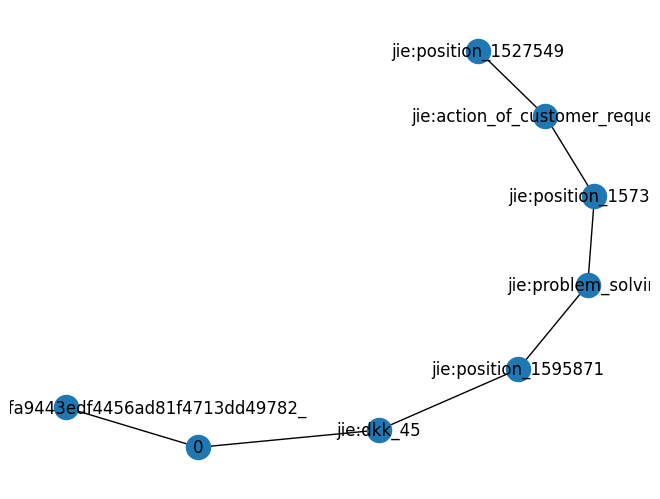

In [14]:
nx.draw_spring(ex, with_labels=True)